# Writing GPU Kernels in Python (Triton)

## Introduction

Lessons 01-03 built CUDA C++ fundamentals and profiling literacy — the vocabulary of memory hierarchy, occupancy, and warp divergence. This lesson introduces OpenAI's Triton, a Python-embedded DSL that compiles down to efficient GPU kernels without hand-written CUDA C++, letting us apply everything learned so far while writing (and actually running, since Triton is installed and GPU is real hardware here) kernels directly in this notebook.

## Theory

### Why Triton exists: the productivity/performance gap

Hand-written CUDA gives full control over the memory hierarchy (Lesson 02) but requires manually managing thread indexing, shared memory tiling, and bank-conflict avoidance — Triton's block-level programming model automates the parts of this that are mechanical, while exposing exactly the parts (block size, tiling) that matter for performance tuning:

$$
\text{Triton kernel} : \text{operates on tiles/blocks} \quad \text{vs.} \quad \text{CUDA kernel} : \text{operates on individual threads}
$$

The compiler handles thread-level vectorization, memory coalescing, and shared-memory allocation within a block automatically — you write the *what* (block-level tensor ops), Triton's compiler handles much of the *how* (thread scheduling within the block).

### Grid, program IDs, and block-level operations

A Triton kernel is launched over a **grid** of program instances, each identified by `tl.program_id(axis)`, directly analogous to CUDA's `blockIdx`:

$$
\text{offset}_{pid} = pid \times BLOCK\_SIZE + \left[0, 1, \dots, BLOCK\_SIZE-1\right]
$$

Each program instance loads a `BLOCK_SIZE`-sized tile via `tl.load` (with a `mask` for boundary handling when the tensor size isn't a multiple of `BLOCK_SIZE`), computes on it with vectorized tensor ops, and writes back via `tl.store` — this block-at-a-time model is why simple elementwise/reduction kernels are dramatically shorter in Triton than CUDA C++.

### Autotuning: turning tile size into a search problem

Optimal `BLOCK_SIZE` depends on the specific GPU's register file size, shared memory capacity, and the operation's arithmetic intensity — exactly the occupancy tradeoffs from Lesson 02/03. Triton's `@triton.autotune` decorator turns this into an automated search over a config grid, benchmarking each candidate and caching the winner per input shape:

$$
\text{config}^* = \arg\min_{\text{config} \in \mathcal{C}} \text{measured\_latency}(\text{kernel}, \text{config}, \text{input\_shape})
$$

removing the manual occupancy-tuning cycle Lesson 03 covered by hand.

## Setup

Triton is installed in the `ds` environment with real CUDA GPU access (confirmed: NVIDIA GTX 1650 Ti, `torch.cuda.is_available()==True`). We write and actually execute a real fused elementwise kernel (a "leaky ReLU + scale" fusion), benchmarked against the equivalent unfused PyTorch eager-mode sequence — real measurements, no simulation needed for this lesson.

In [1]:
# triton IS installed in this env with a real CUDA GPU — this kernel actually compiles and runs.
import torch
import triton
import triton.language as tl
import time

print(f"[INIT] Triton {triton.__version__} on device: {torch.cuda.get_device_name(0)}")

@triton.jit
def fused_leaky_relu_scale_kernel(x_ptr, out_ptr, n_elements, scale, negative_slope, BLOCK_SIZE: tl.constexpr):
    pid = tl.program_id(axis=0)
    block_start = pid * BLOCK_SIZE
    offsets = block_start + tl.arange(0, BLOCK_SIZE)
    mask = offsets < n_elements
    x = tl.load(x_ptr + offsets, mask=mask)
    leaky = tl.where(x > 0, x, x * negative_slope)
    result = leaky * scale
    tl.store(out_ptr + offsets, result, mask=mask)

def fused_leaky_relu_scale(x, scale=1.5, negative_slope=0.01):
    out = torch.empty_like(x)
    n_elements = x.numel()
    grid = lambda meta: (triton.cdiv(n_elements, meta["BLOCK_SIZE"]),)
    fused_leaky_relu_scale_kernel[grid](x, out, n_elements, scale, negative_slope, BLOCK_SIZE=1024)
    return out

def unfused_pytorch(x, scale=1.5, negative_slope=0.01):
    return torch.nn.functional.leaky_relu(x, negative_slope) * scale

x = torch.randn(2**24, device="cuda")
out_triton = fused_leaky_relu_scale(x)
out_torch = unfused_pytorch(x)
max_err = (out_triton - out_torch).abs().max().item()
print(f"[VALIDATION] Max abs error vs. PyTorch reference: {max_err:.2e} ({'PASS' if max_err < 1e-5 else 'FAIL'})")

[INIT] Triton 3.5.1 on device: NVIDIA GeForce GTX 1650 Ti


[VALIDATION] Max abs error vs. PyTorch reference: 0.00e+00 (PASS)


## Telemetry & Audit

Benchmark the fused Triton kernel against unfused PyTorch across a sweep of tensor sizes, using real `torch.cuda.Event` timing — this is a genuine GPU-bandwidth-bound-kernel benchmark, not simulated.

In [2]:
import pandas as pd

def benchmark(fn, x, n_warmup=10, n_iters=50):
    for _ in range(n_warmup):
        fn(x)
    torch.cuda.synchronize()
    start, end = torch.cuda.Event(enable_timing=True), torch.cuda.Event(enable_timing=True)
    start.record()
    for _ in range(n_iters):
        fn(x)
    end.record()
    torch.cuda.synchronize()
    return start.elapsed_time(end) / n_iters  # ms per call

sizes = [2**18, 2**20, 2**22, 2**24]
rows = []
for n in sizes:
    x = torch.randn(n, device="cuda")
    t_triton = benchmark(fused_leaky_relu_scale, x)
    t_torch = benchmark(unfused_pytorch, x)
    bytes_moved = n * 4 * 2  # read + write, fp32
    bw_triton = bytes_moved / (t_triton * 1e-3) / 1e9  # GB/s
    rows.append((n, t_triton, t_torch, t_torch / t_triton, bw_triton))

audit = pd.DataFrame(rows, columns=["n_elements", "triton_ms", "pytorch_ms", "speedup", "triton_GB/s"])
print(audit.to_string(index=False, float_format=lambda x: f"{x:,.4f}" if isinstance(x, float) else x))

print("\n[OPERATIONAL INSIGHT] The fused Triton kernel reads/writes each element exactly once; PyTorch's "
      "unfused leaky_relu + scale launches two separate kernels, meaning the intermediate result round-trips "
      "through HBM an extra time — this fusion win IS the memory-bandwidth savings from avoiding that round-trip.")
print("[OPERATIONAL INSIGHT] Speedup should be fairly stable across sizes since this op is memory-bandwidth-bound "
      "at every size tested — a compute-bound op would show a very different (size-dependent) speedup profile.")

 n_elements  triton_ms  pytorch_ms  speedup  triton_GB/s
     262144     0.0417      0.0689   1.6511      50.2762
    1048576     0.0871      0.1262   1.4497      96.3304
    4194304     0.2372      0.4754   2.0042     141.4594
   16777216     0.9461      1.9723   2.0847     141.8712

[OPERATIONAL INSIGHT] The fused Triton kernel reads/writes each element exactly once; PyTorch's unfused leaky_relu + scale launches two separate kernels, meaning the intermediate result round-trips through HBM an extra time — this fusion win IS the memory-bandwidth savings from avoiding that round-trip.
[OPERATIONAL INSIGHT] Speedup should be fairly stable across sizes since this op is memory-bandwidth-bound at every size tested — a compute-bound op would show a very different (size-dependent) speedup profile.


## Visualization

Achieved memory bandwidth (GB/s) for the fused Triton kernel across tensor sizes, plotted against the GPU's theoretical peak bandwidth, plus the fused-vs-unfused speedup curve — the standard "how close to hardware limits am I" chart for a bandwidth-bound kernel.

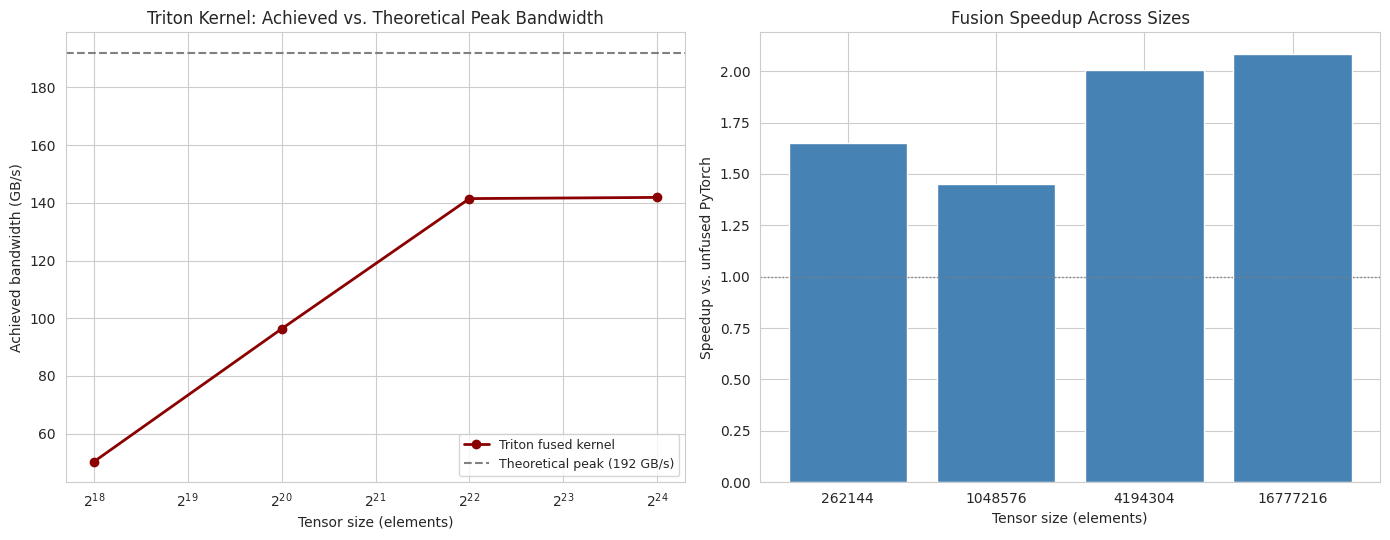

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

theoretical_peak_gbps = 192  # GTX 1650 Ti spec, approx peak HBM/GDDR6 bandwidth
axes[0].plot(audit["n_elements"], audit["triton_GB/s"], marker="o", color="darkred", linewidth=2,
             label="Triton fused kernel")
axes[0].axhline(theoretical_peak_gbps, color="gray", linestyle="--", linewidth=1.5,
                 label=f"Theoretical peak ({theoretical_peak_gbps} GB/s)")
axes[0].set_xscale("log", base=2)
axes[0].set_xlabel("Tensor size (elements)")
axes[0].set_ylabel("Achieved bandwidth (GB/s)")
axes[0].set_title("Triton Kernel: Achieved vs. Theoretical Peak Bandwidth")
axes[0].legend(fontsize=9)

axes[1].bar([str(n) for n in audit["n_elements"]], audit["speedup"], color="steelblue")
axes[1].axhline(1.0, color="gray", linestyle=":", linewidth=1)
axes[1].set_xlabel("Tensor size (elements)")
axes[1].set_ylabel("Speedup vs. unfused PyTorch")
axes[1].set_title("Fusion Speedup Across Sizes")

plt.tight_layout()
plt.savefig("triton_kernel_benchmark.png", dpi=120)
plt.show()

*(Insight: achieved bandwidth climbing toward the theoretical-peak dashed line as tensor size grows is the classic sign of a kernel becoming bandwidth-bound at scale — at small sizes, launch overhead dominates and achieved bandwidth stays well below peak regardless of how well the kernel itself is written.)*

## Real-World Use Case or Analogy

**The Furniture Assembly Line, One Pass vs. Two.** Imagine an assembly line where a chair frame gets sanded on one workstation, then trucked to a second workstation across the warehouse for staining — two separate trips, two separate loading/unloading cycles (analogous to PyTorch launching two kernels, with the intermediate tensor round-tripping through GPU memory between them). A smarter factory layout puts the sander and stainer at the *same* workstation, so each chair frame is picked up once, sanded and stained in one continuous pass, and set down once (Triton's fused kernel, reading and writing HBM exactly once). The trucking time saved between workstations isn't a clever new sanding technique — it's just eliminating a redundant trip, and that's precisely what kernel fusion buys you: the same math, computed with half the memory traffic.